In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False
import yfinance as yf
import numpy as np
import pickle
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime
import seaborn as sns
import os 
import time
sns.set()
import OpenDartReader
from tqdm import tqdm
import requests
import matplotlib.ticker as plt_ticker

In [2]:
# 완성된 gav 기초 데이터 로드
with open('./데이터/gav_data_final.pkl', 'rb') as f :
    basic_gav_data = pickle.load(f)

In [3]:
# 종목명과 티커 매칭을 위한 데이터프레임
ticker_info = pd.read_csv('./데이터/KOSPI200_종목티커정보.csv', encoding='cp949')

# gav_data에 존재하는 종목의 가격 데이터 다운로드
ticker_mapper = {stk_nm : ticker for ticker, stk_nm in ticker_info[['종목코드', '종목명']].iloc}
stknm_mapper = {ticker : stk_nm for ticker, stk_nm in ticker_info[['종목코드', '종목명']].iloc}
yf_gav_tickers = [f'{ticker_mapper[stk_nm]}.KS' for stk_nm in list(basic_gav_data.keys())]
gav_ohlcvs = yf.download(yf_gav_tickers, start='2019-01-01', auto_adjust=True)
gav_prices = gav_ohlcvs['Close']
gav_prices.columns = [tic_col.replace('.KS', '') for tic_col in gav_prices.columns] 
gav_prices.columns = [stknm_mapper[tic_col] for tic_col in gav_prices.columns]

gav_prices.drop('2025-09-19', inplace=True)

[*********************100%***********************]  180 of 180 completed


In [4]:
gav_prices

,하이트진로,유한양행,CJ대한통운,두산,DL,한국앤컴퍼니,기아,SK하이닉스,영풍,현대건설,...,하이브,SK아이이테크놀로지,LG에너지솔루션,DL이앤씨,F&F,SK스퀘어,HD현대마린솔루션,에코프로머티,두산로보틱스,이수스페셜티케미컬
Date,,,,,,,,,,,,,,,,,,,,,
2019-01-02,13529.023438,31356.164062,162175.187500,9.801813e+04,113398.210938,12555.409180,24544.722656,5.628766e+04,62944.707031,47962.980469,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-03,13446.023438,30831.064453,158766.093750,9.473524e+04,114574.546875,12443.639648,24582.138672,5.359404e+04,63201.273438,48685.582031,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-04,13985.523438,33006.496094,159253.109375,9.379727e+04,115162.710938,12480.897461,26078.767578,5.415134e+04,63030.226562,49679.167969,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-07,13902.523438,34206.718750,157792.078125,9.661117e+04,115045.062500,12369.126953,25592.363281,5.452286e+04,63286.792969,51485.683594,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-08,13778.022461,34506.781250,157305.078125,9.754913e+04,114339.265625,12443.639648,25293.035156,5.498729e+04,64227.539062,51756.660156,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-11,16650.000000,84600.000000,97200.000000,1.719000e+06,67000.000000,24650.000000,174700.000000,1.880000e+06,65000.000000,165800.000000,...,241500.0,24500.0,468000.0,91300.0,86100.0,1185453.875,257000.0,75000.0,104400.0,110300.0
2026-05-12,16420.000000,84900.000000,95700.000000,1.676000e+06,61700.000000,23700.000000,168300.000000,1.835000e+06,64200.000000,156000.000000,...,231500.0,22950.0,443000.0,85900.0,83500.0,1124533.375,248500.0,71700.0,101200.0,103600.0
2026-05-13,16300.000000,84700.000000,95400.000000,1.682000e+06,62000.000000,23450.000000,179500.000000,1.976000e+06,63100.000000,160700.000000,...,230500.0,22050.0,430000.0,83200.0,82100.0,1188450.000,232000.0,67800.0,102600.0,106500.0


In [5]:
""" 연간 기준인 Q4 매출액, 당기순이익 값을 3개월 값으로 바꾸는 함수 """
def trans_q4_3m_gav_df(basic_gav_df) :
    
    # Deepcopy : 원본 형태 유지
    gav_df = basic_gav_df.copy()

    # 존재하는 연도 추출 
    exiested_years = pd.to_datetime(gav_df['보고서분기']).dt.year.unique()

    ####################3 여기서는 existed_years 는 모든 분기가 있는 연도에 대해서만 진행해야 한다.

    # 연도 별 Q4 - (Q1 + Q2 + Q3)
    for existed_year in exiested_years :
        
        # 특정 연도 추출
        target_year_df = gav_df[pd.to_datetime(gav_df['보고서분기']).dt.year == existed_year]
        
        # 매출액 Q4 3개월 금액 계산
        quaterly_sales_sum = target_year_df[pd.to_datetime(target_year_df['보고서분기']).dt.month.isin([3,6,9])]['매출액'].sum()
        yearly_sales_sum = target_year_df[pd.to_datetime(target_year_df['보고서분기']).dt.month ==12]['매출액'].values[0]
        q4_3m_sales_value = yearly_sales_sum - quaterly_sales_sum
        
        # 당기순이익 Q4 3개월 금액 계산
        quaterly_earnings_sum = target_year_df[pd.to_datetime(target_year_df['보고서분기']).dt.month.isin([3,6,9])]['당기순이익'].sum()
        yearly_earnings_sum = target_year_df[pd.to_datetime(target_year_df['보고서분기']).dt.month ==12]['당기순이익'].values[0]
        q4_3m_earnings_value = yearly_earnings_sum - quaterly_earnings_sum
        
        # Q4 3개월 값 매칭
        gav_df.loc[gav_df['보고서분기'] == f'{existed_year}-12', '매출액'] = q4_3m_sales_value
        gav_df.loc[gav_df['보고서분기'] == f'{existed_year}-12', '당기순이익'] = q4_3m_earnings_value
        
    return gav_df

# 분기 기준 gav_data 변환
q_gav_data = {stk_nm : trans_q4_3m_gav_df(basic_gav_df) for stk_nm, basic_gav_df in tqdm(basic_gav_data.items())}

100%|██████████| 180/180 [00:31<00:00,  5.75it/s]


In [6]:
def trans_ttm_gav_df(q_gav_df) :
    # Deepcopy : 원본 형태 유지
    gav_df = q_gav_df.copy()

    # TTM 매출액, 당기순이익 데이터 매칭
    gav_df['매출액'] = gav_df['매출액'].rolling(4).sum()
    gav_df['당기순이익'] = gav_df['당기순이익'].rolling(4).sum()

    return gav_df

# TTM 기준 gav_data 변환
ttm_gav_data = {stk_nm : trans_ttm_gav_df(q_gav_df) for stk_nm, q_gav_df in tqdm(q_gav_data.items())}

  0%|          | 0/180 [00:00<?, ?it/s]

100%|██████████| 180/180 [00:00<00:00, 208.67it/s]


In [7]:
# 주식총수 시계열 데이터 프레임
stk_counts = pd.DataFrame().reindex_like(gav_prices)

# 보고서 공개일 기준 주식총수 매칭
for stk_nm, gav_df in ttm_gav_data.items() :
    for update_date, stk_count in gav_df[['보고서최초공개일', '주식총수']].iloc :
        stk_counts.loc[update_date, stk_nm] = stk_count 
stk_counts = stk_counts.ffill()

# 시가총액 (= 주식총수 X 가격) 데이터프레임 생성
market_caps = stk_counts * gav_prices

In [8]:
# TTM 당기순이익 시계열 데이터 프레임
ttm_earings = pd.DataFrame().reindex_like(gav_prices)

# 보고서 공개일 기준 TTM 당기순이익 매칭
for stk_nm, gav_df in ttm_gav_data.items() :
    for update_date, ttm_earing in gav_df[['보고서최초공개일', '당기순이익']].iloc :
        ttm_earings.loc[update_date, stk_nm] = ttm_earing 
ttm_earings = ttm_earings.ffill()

# TTM 매출액 시계열 데이터 프레임
ttm_sales = pd.DataFrame().reindex_like(gav_prices)

# 보고서 공개일 기준 TTM 매출액 매칭
for stk_nm, gav_df in ttm_gav_data.items() :
    for update_date, ttm_sale in gav_df[['보고서최초공개일', '매출액']].iloc :
        ttm_sales.loc[update_date, stk_nm] = ttm_sale 
ttm_sales = ttm_sales.ffill()

# 총자본 시계열 데이터 프레임
books = pd.DataFrame().reindex_like(gav_prices)

# 보고서 공개일 기준 총자본 매칭
for stk_nm, gav_df in ttm_gav_data.items() :
    for update_date, book in gav_df[['보고서최초공개일', '총자본']].iloc :
        books.loc[update_date, stk_nm] = book 
books = books.ffill()

In [9]:
# E/P, S/P, B/P 수치값 계산
e_ps = ttm_earings / market_caps
s_ps = ttm_sales / market_caps
b_ps = books / market_caps

# winsorizing 함수 : 양 극단 5% 제거
def winsorizing(df, lower_at = 0.05, upper_at = 1-0.05):
    return df.clip(
            lower=df.quantile(lower_at, axis=1), 
            upper=df.quantile(upper_at, axis=1), 
            axis=0) 

# Z-Scoring 함수 
def z_scoring(row):
    std = row.std()
    # 전부 nan 항이면
    if std == 0 or pd.isna(std):
        return row * 0
    return (row - row.mean()) / std

# Winsorizing 
winsor_e_ps = winsorizing(e_ps)
winsor_s_ps = winsorizing(s_ps)
winsor_b_ps = winsorizing(b_ps)

# Z-Scoring
ze_ps = winsor_e_ps.apply(z_scoring, axis=1)
zs_ps = winsor_s_ps.apply(z_scoring, axis=1)
zb_ps = winsor_b_ps.apply(z_scoring, axis=1)

# 최종 Value Scoring
value_scores = (ze_ps + zs_ps + zb_ps) / 3

# Ranking (값이 클수록(= PER, PBR, PSR 관점에서 저평가일수록) 1등)
ze_ps_ranking = ze_ps.rank(axis=1, ascending=False)
zs_ps_ranking = zs_ps.rank(axis=1, ascending=False)
zb_ps_ranking = zb_ps.rank(axis=1, ascending=False)
value_ranking = value_scores.rank(axis=1, ascending=False)

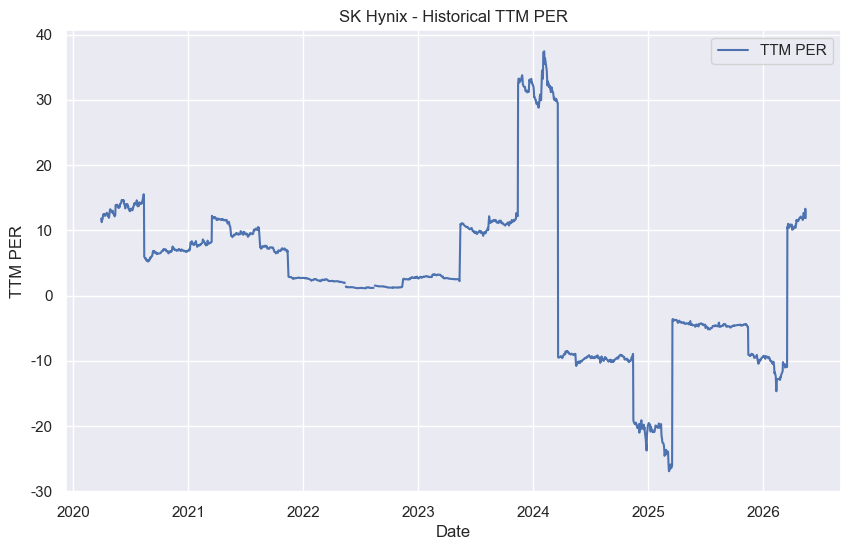

In [10]:
target_ticker = '이마트'
plt.figure(figsize=(10,6))
plt.plot((1/e_ps)[target_ticker], label = 'TTM PER')
plt.legend()
plt.xlabel('Date')
plt.ylabel('TTM PER')
plt.title(f'SK Hynix - Historical TTM PER')
plt.show()


In [11]:
def trans_delta_gav_df(ttm_gav_df) :
    # Deepcopy : 원본 형태 유지
    gav_df = ttm_gav_df.copy()

    # TTM 매출액, 당기순이익 Delta 데이터 매칭
    gav_df['매출액_delta'] = gav_df['매출액'] - gav_df['매출액'].shift()
    gav_df['당기순이익_delta'] = gav_df['당기순이익'] - gav_df['당기순이익'].shift()

    return gav_df

# TTM Delta 기준 gav_data 변환
delta_gav_data = {stk_nm : trans_delta_gav_df(ttm_gav_df) for stk_nm, ttm_gav_df in tqdm(ttm_gav_data.items())}

100%|██████████| 180/180 [00:00<00:00, 251.84it/s]


In [12]:
# TTM 당기순이익 Delta 시계열 데이터 프레임
delta_earnings = pd.DataFrame().reindex_like(gav_prices)

# 보고서 공개일 기준 TTM 당기순이익 Delta 매칭
for stk_nm, gav_df in delta_gav_data.items() :
    for update_date, ttm_earning_delta in gav_df[['보고서최초공개일', '당기순이익_delta']].iloc :
        delta_earnings.loc[update_date, stk_nm] = ttm_earning_delta 
delta_earnings = delta_earnings.ffill()


# TTM 매출액 Delta 시계열 데이터 프레임
delta_sales = pd.DataFrame().reindex_like(gav_prices)

# 보고서 공개일 기준 TTM 매출액 Delta 매칭
for stk_nm, gav_df in delta_gav_data.items() :
    for update_date, ttm_sale_delta in gav_df[['보고서최초공개일', '매출액_delta']].iloc :
        delta_sales.loc[update_date, stk_nm] = ttm_sale_delta 
delta_sales = delta_sales.ffill()


In [13]:
# 시가총액기반 TTM 매출액, 당기순이익, N개월 샤프비율 수치값 계산
earning_growth = delta_earnings / market_caps
sales_growth = delta_sales / market_caps
gav_rets = gav_prices.pct_change()
sharpe_mom = gav_rets.rolling(20 * 3).mean() *  np.sqrt(252) / gav_rets.rolling(20 * 3).std()


# winsorizing 함수 : 양 극단 5% 제거
def winsorizing(df, lower_at = 0.05, upper_at = 1-0.05):
    return df.clip(
            lower=df.quantile(lower_at, axis=1), 
            upper=df.quantile(upper_at, axis=1), 
            axis=0) 

# Z-Scoring 함수 
def z_scoring(row):
    std = row.std()
    # 전부 nan 항이면
    if std == 0 or pd.isna(std):
        return row * 0
    return (row - row.mean()) / std

# Winsorizing 
winsor_earning_growth = winsorizing(earning_growth)
winsor_sales_growth = winsorizing(sales_growth)
winsor_sharpe_mom = winsorizing(sharpe_mom)

# Z-Scoring
z_earning_growth = winsor_earning_growth.apply(z_scoring, axis=1)
z_sales_growth = winsor_sales_growth.apply(z_scoring, axis=1)
z_sharpe_mom = winsor_sharpe_mom.apply(z_scoring, axis=1)

# 최종 Value Scoring
growth_scores = (z_earning_growth + z_sales_growth + z_sharpe_mom) / 3

# Ranking (값이 클수록(= PER, PBR, PSR 관점에서 저평가일수록) 1등)
z_earning_growth_ranking = z_earning_growth.rank(axis=1, ascending=False)
z_sales_growth_ranking = z_sales_growth.rank(axis=1, ascending=False)
z_sharpe_mom_ranking = z_sharpe_mom.rank(axis=1, ascending=False)
growth_ranking = growth_scores.rank(axis=1, ascending=False)

In [14]:
# 성장조정가치 Score
vg_scores = (value_scores + growth_scores) / 2 
vg_ranking = vg_scores.rank(axis=1, ascending = False)
vg_ranking.loc['2026-04-14'].nsmallest(5)

이마트     1.0
영풍      2.0
롯데쇼핑    3.0
동원산업    4.0
GS      5.0
Name: 2026-04-14 00:00:00, dtype: float64

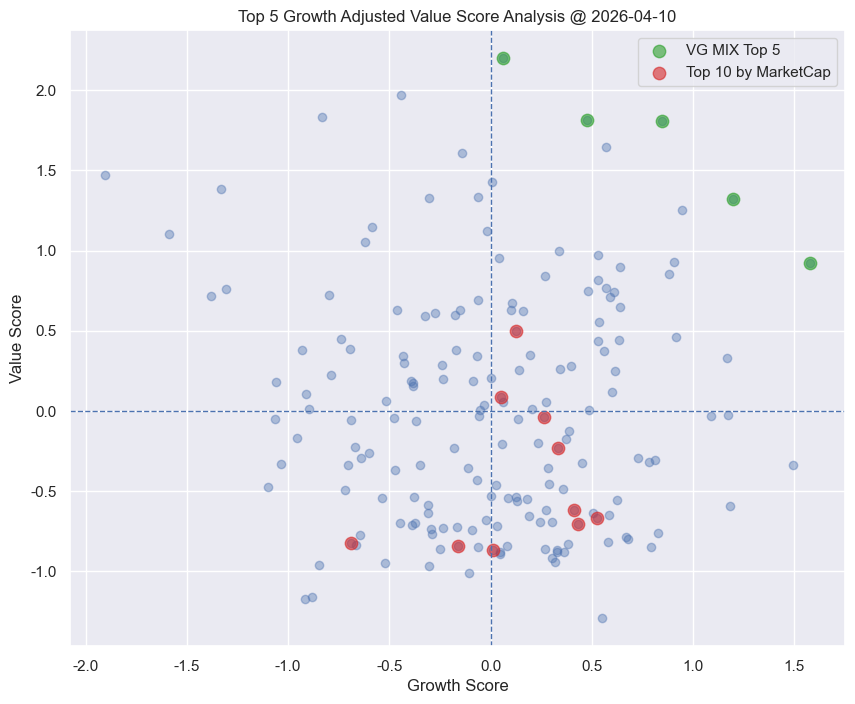

In [15]:
# 타겟일 지정 및 성장, 가치 Score 추출
target_date = '2026-04-10'
top_selection = 5
value_at = value_scores.loc[target_date]
growth_at = growth_scores.loc[target_date]
vg_mix_topn = vg_ranking.loc[target_date].nsmallest(top_selection)
topn_corps = list(vg_mix_topn.index)
market_cap_top10 = ['삼성전자', 'SK하이닉스', '현대차', 'LG에너지솔루션', '한화에어로스페이스', 'SK스퀘어', '삼성바이오로직스', '두산에너빌리티', '기아', '삼성물산']

# 성장 조정 가치 Score 4분면 시각화
plt.figure(figsize=(10,8))
plt.scatter(growth_at, value_at, alpha = 0.4) 
plt.scatter(growth_at[topn_corps], value_at[topn_corps], alpha=0.6, color="tab:green", s=80, label=f'VG MIX Top {top_selection}') 
plt.scatter(growth_at[market_cap_top10], value_at[market_cap_top10], alpha=0.6, color="tab:red", s=80, label=f'Top 10 by MarketCap') 
plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel('Growth Score')
plt.ylabel('Value Score')
plt.title(f'Top {top_selection} Growth Adjusted Value Score Analysis @ {target_date}')
plt.legend()
plt.show()



# GAV 전략

#### 트레일링 스탑 기반 3atr 스탑로스 시계열 데이터프레임 구하기

In [16]:
closes = gav_ohlcvs['Close']
highs = gav_ohlcvs['High']
lows = gav_ohlcvs['Low']
opens = gav_ohlcvs['Open']

closes.columns = [tic_col.replace('.KS', '') for tic_col in closes.columns] 
closes.columns = [stknm_mapper[tic_col] for tic_col in closes.columns]
highs.columns = [tic_col.replace('.KS', '') for tic_col in highs.columns] 
highs.columns = [stknm_mapper[tic_col] for tic_col in highs.columns]
lows.columns = [tic_col.replace('.KS', '') for tic_col in lows.columns] 
lows.columns = [stknm_mapper[tic_col] for tic_col in lows.columns]
opens.columns = [tic_col.replace('.KS', '') for tic_col in opens.columns] 
opens.columns = [stknm_mapper[tic_col] for tic_col in opens.columns]

closes.drop('2025-09-19', inplace=True)
highs.drop('2025-09-19', inplace=True)
lows.drop('2025-09-19', inplace=True)
opens.drop('2025-09-19', inplace=True)

In [17]:
def cal_true_range(target_date, stock_price_df) :

    # Today/Yesterday Date idx
    today_date_idx = stock_price_df.index.get_loc(target_date)
    yesterday_date_idx = today_date_idx - 1

    # t-high, t-low, {t-1}-close
    t_high = stock_price_df['High'].iloc[today_date_idx]
    t_low = stock_price_df['Low'].iloc[today_date_idx]
    t1_close = stock_price_df['Close'].iloc[yesterday_date_idx]

    # Calculate True Range
    true_range = np.max([np.abs(t_high - t_low), np.abs(t1_close - t_high), np.abs(t1_close - t_low)])

    return true_range

def cal_arc_level(target_stock, arc_param = 3, search_range = 20) : 
    # 특정 종목의 OHLC 데이터 추출 
    close = closes[target_stock]
    high = highs[target_stock]
    low = lows[target_stock]
    open = opens[target_stock]

    # 특정 종목의 OHLC 가격 데이터 프레임
    stock_price_df = pd.DataFrame(close)
    stock_price_df.columns = ['Close']
    stock_price_df['Open'] = open
    stock_price_df['Low'] = low
    stock_price_df['High'] = high
    stock_price_df.columns.name = target_stock

    # True Range, ATR, ARC = 3ATR
    stock_price_df['TR'] = pd.Series({target_date : cal_true_range(target_date, stock_price_df) for i, target_date in enumerate(close.index) if i != 0})
    stock_price_df.dropna(inplace=True)
    stock_price_df['ATR'] = stock_price_df['TR'].rolling(search_range).mean()
    stock_price_df[f'ARC'] = stock_price_df['ATR'] * arc_param

    return stock_price_df['ARC']

In [18]:
arc_levels = pd.DataFrame().reindex_like(gav_prices)

for target_stock in tqdm(list(ttm_gav_data.keys())) :
    arc_levels[target_stock] = cal_arc_level(target_stock, arc_param = 2)

100%|██████████| 180/180 [01:17<00:00,  2.33it/s]


In [19]:
# 단순 빼기이므로 Trailing Stop은 아닌 상태임. -> 이때 Trailing Stop을 적용하기 위해서는 실제 투입 시기를 기준으로 해야하므로 추후 선정된 종목에 한해서 Trailing Stop을 투입 시기 기준 cummax 로 해석함.
stop_losses = gav_prices - arc_levels

In [20]:
stop_losses.loc['2026-03-27' : , '하이트진로'].cummax()['2026-04-10']

16691.0

#### Ranking Top N 유지기간 매칭 시계열 만들기 

In [21]:
# 종목 별 TOP N 유지 기간 매칭 시계열 데이터프레임
ranking_selection_periods = pd.DataFrame().reindex_like(gav_prices).fillna(0)

# TOP N 넘버 
topn = 5

# TOP N 이 잡히는 시점의 등수 총합
cal_standard = np.array(range(1, topn+1)).sum()

# 최초 TOP N이 잡히는 시점 필터링 넘버 : 후보군 변화 감지 에러 방지 차원
initial_date = False

# 일 별 TOP N 종목 추출
for daily_ranking_info in vg_ranking.iloc :
    
    # 일자 및 후보군 탐색 
    candidates = daily_ranking_info.nsmallest(topn)
    now_date = candidates.name

    # TOP N 잡히는 시점 필터링
    if candidates.sum() == cal_standard : 

        # 최초 TOP N 선별 시    
        if not initial_date :

            # 최초 선별 시점 매칭
            initial_date = candidates.name.strftime('%Y-%m-%d')
            
            # TOP N 선별 정보 기록
            now_topn = list(candidates.index) 
            for topn_stock in now_topn :
                ranking_selection_periods.loc[now_date, topn_stock] += 1
            
            # 정보 기록 후 선별 종목 과거 시점으로 전환
            past_topn = now_topn
            past_date = now_date
            continue 
        
        # 최초 TOP N 선별 시점이 아닌 경우 (almost)
        now_topn = list(candidates.index)

        # 유지 종목
        maintained_stocks = list(set(now_topn).intersection(set(past_topn)))
        if maintained_stocks :
            for maintained_stock in maintained_stocks :
                ranking_selection_periods.loc[now_date, maintained_stock] = ranking_selection_periods.loc[past_date, maintained_stock] + 1

        # 신규 종목
        new_stocks = list(set(now_topn).difference(set(past_topn)))
        if new_stocks :
            for new_stock in new_stocks :
                ranking_selection_periods.loc[now_date, new_stock] += 1

        # 편출 종목 : 이미 0으로 맵핑 되어 있으므로 SKIP 
        deleted_stocks = list(set(past_topn).difference(set(now_topn)))

        # 정보 기록 후 선별 종목 과거 시점으로 전환
        past_topn = now_topn
        past_date = now_date


#### 재진입 조건을 위한 20일 이평선 

In [22]:
ma20 = gav_prices.rolling(20).mean()

#### 종목 별 매수 가능 수주 구하기 

In [23]:
def cal_inv_cnt(available_inv, price_at) :
    # 종목 1주 가격이 투자 가능 금액보다 큰 경우
    if price_at >= available_inv :
        inv_cnt = 1
    # 종목 1주 가격이 투자 가능 금액보다 작은 경우
    else :
        inv_cnt = np.floor(available_inv / price_at)
    return int(inv_cnt)

#### gav 전략 구현

In [ ]:
# 최초 투자 원금 
initial_cash = 15000000

# 누적 실현 손익
realized_cum = 0

# TOP N 넘버 
topn = 5

# TOP N 이 잡히는 시점의 등수 총합
cal_standard = np.array(range(1, topn+1)).sum()

# 최초 TOP N이 잡히는 시점 필터링 넘버 : 후보군 변화 감지 에러 방지 차원
initial_date = False

# 일 별 투자 현황 기록 딕셔너리 {일자 : [일 별 투자 현황 데이터프레임, 트레이딩 히스토리 결과]}
inv_records = {}

# 투자했던 기업의 리스트 
holding_stocks = []


# 전체 길이 미리 계산
total_length = len(vg_ranking)



# 일 별 트레이딩 기록 
for i in tqdm(range(total_length), total=total_length, desc="백테스트 진행중"):
    
    # 일 별, 종목 별 vag ranking 추출
    daily_ranking_info = vg_ranking.iloc[i]

    # 일 별 투자 현황 저장 딕셔너리
    now_inv_records = {}
    
    # 일자 및 후보군 탐색 
    now_cadidates = daily_ranking_info.nsmallest(topn)
    
    now_date = now_cadidates.name.strftime('%Y-%m-%d')

    # TOP N 잡히는 시점 필터링
    if now_cadidates.sum() == cal_standard : 

        # 최초 TOP N 투자 시    
        if not initial_date :

            now_inv_stocks = list(now_cadidates.index) 

            # 최초 선별 시점 매칭
            initial_date = now_cadidates.name.strftime('%Y-%m-%d')

            # 최초 투자 가능 금액 
            total_inv_available_money = initial_cash

            # 종목 당 투자 가능 금액 
            stock_inv_available_money = total_inv_available_money * 0.12

            # 투자 종목 
            now_inv_records['종목명'] = [stk for stk in list(now_cadidates.index)]

            # 진입 날짜
            entry_dates = [now_date for _ in now_inv_stocks]
            now_inv_records['진입날짜'] = entry_dates

            # top5 유지기간
            existed_days = [int(ranking_selection_periods.loc[now_date, stk]) for stk in list(now_cadidates.index)]
            now_inv_records['top5_유지기간'] = existed_days

            # 매매상태 
            now_inv_records['매매상태'] = ['신규' for _ in list(now_cadidates.index)]

            # 투자 종목 진입 가격
            entry_prices = [int(gav_prices.loc[now_date, stk]) for stk in list(now_cadidates.index)]
            now_inv_records['진입가격'] = entry_prices

            # 투자 종목 현재 가격
            now_prices = entry_prices
            now_inv_records['현재가격'] = now_prices

            # 투자 종목 보유 주수
            qtys = [cal_inv_cnt(stock_inv_available_money, entry_price) for entry_price in entry_prices]
            now_inv_records['qty'] = qtys

            # 스탑로스 
            stop_loss_values = [int(stop_losses.loc[now_date, stk]) for stk in list(now_cadidates.index)]
            now_inv_records['stop_loss'] = stop_loss_values

            # 스탑로스 %
            stop_loss_pcts = np.round((np.array(stop_loss_values) / np.array(entry_prices)) - 1, 2) * 100
            now_inv_records['stop_loss(%)'] = stop_loss_pcts

            # PNL
            pnls = list((np.array(now_prices) - np.array(entry_prices)) * np.array(qtys))
            now_inv_records['pnl'] = pnls  

            # 일 별 매매정보 데이터프레임
            now_inv_records_df = pd.DataFrame(now_inv_records)

            # 트레이딩 히스토리
            trading_history = {}
            trading_history['투자금'] = [(now_inv_records_df['진입가격'] * now_inv_records_df['qty']).sum()]
            trading_history['현금'] = [initial_cash - trading_history['투자금'][0]]
            trading_history['현금비중'] = [np.round(trading_history['현금'][0] / initial_cash, 2)]
            trading_history['투자비중'] = [np.round(trading_history['투자금'][0] / initial_cash, 2)]
            trading_history['누적실현손익'] = [realized_cum]
            trading_history['현재미실현손익'] = [0]

            trading_history_df = pd.DataFrame(trading_history)[['현금', '현금비중', '투자금', '투자비중', '누적실현손익', '현재미실현손익']]
            inv_records[now_date] = {'inv_record' : now_inv_records_df, 'inv_history' : trading_history_df} 
            
            # 투자 종목 기록
            holding_stocks.extend(now_inv_stocks)

            # 정보 기록 후 선별 종목 과거 시점으로 전환
            past_date = now_date
            past_inv_stocks = now_inv_stocks
            continue
    
        ################################################# 최초 이후 트레이딩 처리 로직 ###################################################
        ################################ 최초 이후 트레이딩 처리 로직 - inv_record 관련 ###################################################

        # 과거 inv_record 복사 및 편출 정보 삭제
        now_inv_records_df_tmp = inv_records[past_date]['inv_record']
        now_inv_records_df = now_inv_records_df_tmp[now_inv_records_df_tmp['매매상태'].isin(['신규', '유지'])]

        past_inv_stocks = now_inv_records_df['종목명'].to_list()
        
        # 당일 top5 종목 
        now_inv_stocks = list(now_cadidates.index) 
        #################################################################################################################################
        # top5 유지 종목
        maintained_stocks = list(set(now_inv_stocks).intersection(set(past_inv_stocks)))

        # top5 유지 종목 + not 청산 기업
        mcn_stocks = [maintained_stock for maintained_stock in maintained_stocks if gav_prices.loc[now_date][maintained_stock]  > stop_losses.loc[now_date][maintained_stock]]
        
        # top5 유지 종목 + 청산 기업
        mcy_stocks = [maintained_stock for maintained_stock in maintained_stocks if gav_prices.loc[now_date][maintained_stock]  <= stop_losses.loc[now_date][maintained_stock]]
        ################################################################################################################################
        # top5 편출 종목 
        deleted_stocks = list(set(past_inv_stocks).difference(set(now_inv_stocks)))

        # top5 편출 종목 + not 청산 기업
        dcn_stocks = [deleted_stock for deleted_stock in deleted_stocks if gav_prices.loc[now_date][deleted_stock]  >  stop_losses.loc[now_inv_records_df.loc[now_inv_records_df['종목명'] == deleted_stock, '진입날짜'].values[0] : , deleted_stock].cummax()[now_date]]
        
        # top5 편출 종목 + 청산 기업
        dcy_stocks = [deleted_stock for deleted_stock in deleted_stocks if gav_prices.loc[now_date][deleted_stock]  <=  stop_losses.loc[now_inv_records_df.loc[now_inv_records_df['종목명'] == deleted_stock, '진입날짜'].values[0] : , deleted_stock].cummax()[now_date]]

 
        ################################################################################################################################
        # 신규 편입 종목 
        new_stocks = list(set(now_inv_stocks).difference(set(past_inv_stocks)))

        # 신규 편입 (역사적 첫 편입)
        nhf_stocks = [new_stock for new_stock in new_stocks if not (new_stock in holding_stocks) and not (new_stock in past_inv_stocks)]
        
        # 신규 편입 (재진입)
        nhe_stocks = [new_stock for new_stock in new_stocks if (new_stock in holding_stocks) and not (new_stock in past_inv_stocks)]

        ################################################################################################################################
        # 청산 또는 미청산 그룹
        cn_stocks = mcn_stocks + dcn_stocks
        cy_stocks = mcy_stocks + dcy_stocks

        # 유지 또는 편출 그룹
        if (maintained_stocks + deleted_stocks) : 
            for stknm in (maintained_stocks + deleted_stocks) :
                
                # top5 보유기간 업데이트
                now_inv_records_df.loc[now_inv_records_df['종목명']== stknm, 'top5_유지기간'] = int(ranking_selection_periods.loc[now_date][stknm])
                # 현재가격 업데이트
                now_inv_records_df.loc[now_inv_records_df['종목명']== stknm, '현재가격'] = int(gav_prices.loc[now_date][stknm])
                # Stop_Loss 업데이트
                now_inv_records_df.loc[now_inv_records_df['종목명']== stknm, 'stop_loss'] = \
                                            int((stop_losses.loc[now_inv_records_df.loc[now_inv_records_df['종목명'] == stknm]['진입날짜'].values[0] : ][stknm]).cummax()[now_date])
                # Stop_Loss(%) 업데이트
                now_inv_records_df.loc[now_inv_records_df['종목명']== stknm, 'stop_loss(%)'] = \
                    np.round(((now_inv_records_df.loc[now_inv_records_df['종목명'] == stknm]['stop_loss'].values[0] / now_inv_records_df.loc[now_inv_records_df['종목명'] == stknm]['진입가격'].values[0]) - 1) * 100, 2)
                
                # PnL 업데이트
                price_delta = (now_inv_records_df.loc[now_inv_records_df['종목명'] == stknm]['현재가격'].values[0] - now_inv_records_df.loc[now_inv_records_df['종목명'] == stknm]['진입가격'].values[0])
                qty = now_inv_records_df.loc[now_inv_records_df['종목명'] == stknm]['qty'].values[0]
                now_inv_records_df.loc[now_inv_records_df['종목명']== stknm, 'pnl'] = price_delta * qty

                # 미청산 그룹에 속할 시 
                if stknm in cn_stocks :
                    now_inv_records_df.loc[now_inv_records_df['종목명']== stknm, '매매상태'] = '유지'
                
                # 청산 그룹에 속할 시
                elif stknm in cy_stocks: 
                    now_inv_records_df.loc[now_inv_records_df['종목명']== stknm, '매매상태'] = '편출'
        
        ################################################################################################################################
        if (nhf_stocks + nhe_stocks) : 
            # 재진입 조건 충족 그룹 
            if nhe_stocks :
                nre_entry_stocks = [nhe_stock for nhe_stock in nhe_stocks if gav_prices.loc[now_date][stknm] > ma20.loc[now_date][stknm]]
            else : 
                nre_entry_stocks = []
            
            # 역사적 첫 편입 그룹 + 재진입 조건 충족 그룹
            ne_stocks = nhf_stocks + nre_entry_stocks
            
            # 종목 당 투자 금액 = (과거) (누적실현손익이 반영된 현금 + 투자금) 의 8% 
            stock_inv_available_money = int(inv_records[past_date]['inv_history'][['현금', '투자금']].sum(axis=1).values[0] * 0.12)

            # 현금 제약 하 투자 가능 종목 수
            available_stk_cnt = int(np.clip(inv_records[past_date]['inv_history']['현금'].values[0] / stock_inv_available_money, 0, len(ne_stocks)))

            # 현금 제약 하 신규 투자 종목 선정 : gav Score Ranking이 높은 종목을 우선 순위로
            new_available_stocks = now_cadidates[ne_stocks].nsmallest(int(available_stk_cnt))

            # 신규 편입 종목에 투자할 현금이 있는 경우 
            if not new_available_stocks.empty : 
                
                actual_buy_list = []
                entry_prices = []
                qtys = []
                
                # 현재 가용 현금을 순차적으로 차감하며 매수
                current_usable_cash = inv_records[past_date]['inv_history']['현금'].values[0]
                
                for stk in new_available_stocks.index:
                    price = int(gav_prices.loc[now_date, stk])
                    
                    # 주가가 가용 현금보다 비싼 경우 -> 매수 X  
                    if price > current_usable_cash:
                        continue 
                        
                    # 신규 매수 가능한 경우 

                    # 종목 당 투자금액보다 주가가 비싼 경우 
                    if price >= stock_inv_available_money:
                        qty = 1  
                    # 종목 당 투자금액보다 주가가 싼 경우
                    else:
                        qty = int(np.floor(stock_inv_available_money / price))
                    
                    # 총 비용이 현재 남은 현금을 넘지 않도록 2차 방어
                    buy_cost = price * qty
                    if buy_cost > current_usable_cash:
                        # 남은 돈으로 살 수 있는 최대치로 재조정
                        qty = int(np.floor(current_usable_cash / price)) 
                        buy_cost = price * qty
                        # 재조정했는데 0주면 패스
                        if qty == 0: 
                            continue 
                    
                    # 매수 확정 및 정보 기록
                    actual_buy_list.append(stk)
                    entry_prices.append(price)
                    qtys.append(qty)
                    
                    # 매수 기록 : 현금 차감
                    current_usable_cash -= buy_cost 

                # 현금 제약 하 신규 구매가 발생한 경우
                if actual_buy_list: 
                    new_inv_records = {}
                    new_inv_records['종목명'] = actual_buy_list
                    new_inv_records['진입날짜'] = [now_date for _ in actual_buy_list]
                    new_inv_records['top5_유지기간'] = [int(ranking_selection_periods.loc[now_date, stk]) for stk in actual_buy_list]
                    new_inv_records['매매상태'] = ['신규' for _ in actual_buy_list]
                    new_inv_records['진입가격'] = entry_prices
                    new_inv_records['현재가격'] = entry_prices
                    new_inv_records['qty'] = qtys
                    stop_loss_values = [int(stop_losses.loc[now_date, stk]) for stk in actual_buy_list]
                    new_inv_records['stop_loss'] = stop_loss_values
                    stop_loss_pcts = np.round((np.array(stop_loss_values) / np.array(entry_prices)) - 1, 2) * 100
                    new_inv_records['stop_loss(%)'] = stop_loss_pcts
                    pnls = list((np.array(entry_prices) - np.array(entry_prices)) * np.array(qtys)) # 진입 당일 PNL은 0
                    new_inv_records['pnl'] = pnls  
                    new_inv_records_df = pd.DataFrame(new_inv_records)
                    now_inv_records_df = pd.concat([now_inv_records_df, new_inv_records_df]).reset_index(drop=True)
            
        
        ################################ 최초 이후 트레이딩 처리 로직 - inv_history 관련 ###################################################
        
        trading_history_df = inv_records[past_date]['inv_history'].copy()

        # 미실현손익: '유지' 및 '신규' 상태인 종목들의 pnl 합산
        trading_history_df['현재미실현손익'] = now_inv_records_df[now_inv_records_df['매매상태'].isin(['유지', '신규'])]['pnl'].sum()
        
        # 매매상태가 '신규'인 경우: 새로 산 만큼 투자금을 늘리고, 현금을 차감
        new_stocks_df = now_inv_records_df[now_inv_records_df['매매상태'] == '신규']
        if not new_stocks_df.empty:
            new_input_money = (new_stocks_df['진입가격'] * new_stocks_df['qty']).sum()
            trading_history_df['투자금'] = trading_history_df['투자금'] + new_input_money
            trading_history_df['현금'] = trading_history_df['현금'] - new_input_money
        
        # 매매상태가 '편출'인 경우: 원금 회수 및 실현손익 반영
        exit_stocks_df = now_inv_records_df[now_inv_records_df['매매상태'] == '편출']
        if not exit_stocks_df.empty:
            # 실현손익 누적
            realized = exit_stocks_df['pnl'].sum()
            realized_cum += realized
            
            # 회수된 원금 계산 (투자금에서 빼고 현금으로 돌려줘야 함)
            recovered_principal = (exit_stocks_df['진입가격'] * exit_stocks_df['qty']).sum()
            
            # 자산 이동 (투자금 감소, 현금은 원금+수익만큼 증가)
            trading_history_df['투자금'] = trading_history_df['투자금'] - recovered_principal
            trading_history_df['현금'] = trading_history_df['현금'] + recovered_principal + realized
            trading_history_df['누적실현손익'] = realized_cum

        # 중 업데이트 
        total_amount = trading_history_df['현금'].values[0] + trading_history_df['투자금'].values[0]
        trading_history_df['현금비중'] = np.round(trading_history_df['현금'].values[0] / total_amount, 2)
        trading_history_df['투자비중'] = np.round(trading_history_df['투자금'].values[0] / total_amount, 2)


        ################################ 최초 이후 트레이딩 처리 로직 - 정보 기록 후 선별 종목 과거 시점으로 전환 ###################################################
        # 투자 종목 기록
        holding_stocks.extend(now_inv_stocks)
        holding_stocks = list(set(holding_stocks))

        # 일자 별 트레이딩 정보 매칭
        inv_records[now_date] = {'inv_record' : now_inv_records_df, 'inv_history' : trading_history_df} 

        # 정보 기록 후 선별 종목 과거 시점으로 전환
        past_date = now_date
        past_inv_stocks = now_inv_records_df['종목명'].to_list()

        # if i == 500 :
        #     break

백테스트 진행중:   0%|          | 0/1808 [00:00<?, ?it/s]

백테스트 진행중: 100%|██████████| 1808/1808 [04:57<00:00,  6.07it/s]


In [25]:
# 일 별 PnL History 계산
gav_pnl_history = {}
for day, gav_infos_tmp in inv_records.items() :
    gav_history = gav_infos_tmp['inv_history']
    pnl_value = gav_history['현금'].values[0] + gav_history['투자금'].values[0] + gav_history['현재미실현손익'].values[0]
    gav_pnl_history[day] = pnl_value

[*********************100%***********************]  1 of 1 completed


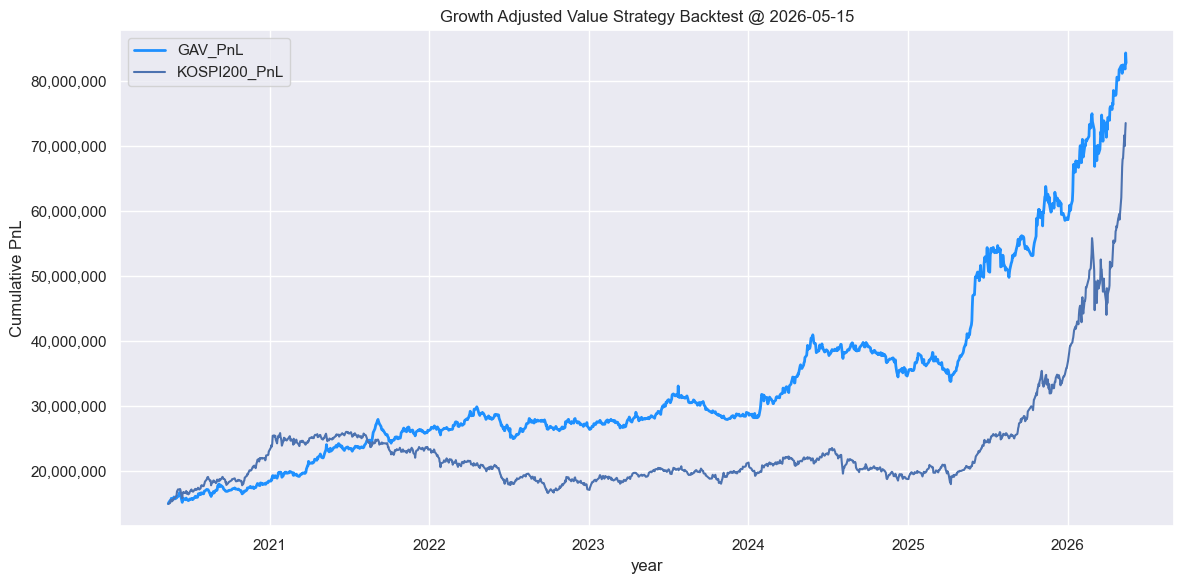

In [26]:
########################### 시각화 #########################

# 시계열 x 축 생성
pnl_series = pd.Series(gav_pnl_history)
pnl_series.index = pd.to_datetime(pnl_series.index)

# 벤치마크 : KOSPI200
start_date = pnl_series.index[0]
end_date = pnl_series.index[-1] 
kospi_df = yf.download('^KS200', start=start_date, end=end_date)
initial_cash = 15000000
kospi_return = kospi_df['Close'] / kospi_df['Close'].iloc[0]
kospi_pnl = initial_cash * kospi_return

# 시각화 
plt.figure(figsize=(12, 6))
plt.plot(pnl_series.index, pnl_series.values, color='dodgerblue', linewidth=2, label = 'GAV_PnL')
plt.plot(kospi_pnl.index, kospi_pnl.values, label = 'KOSPI200_PnL')
plt.title(f'Growth Adjusted Value Strategy Backtest @ {pnl_series.index[-1].strftime("%Y-%m-%d")}')
plt.xlabel('year')
plt.ylabel('Cumulative PnL')
plt.legend()
plt.gca().yaxis.set_major_formatter(plt_ticker.StrMethodFormatter('{x:,.0f}'))
plt.tight_layout()
plt.show()



# 지금 성장 조정 점수에서 q_gav_data, ttm_gav_data를 사용하는 2가지 버전으로 테스트 중임

In [27]:
rct_day = list((inv_records.keys()))[-1]
inv_records[rct_day]['inv_record']

,종목명,진입날짜,top5_유지기간,매매상태,진입가격,현재가격,qty,stop_loss,stop_loss(%),pnl
2,롯데쇼핑,2026-03-17,1,유지,100966,173300,66,156890,55.39,4774044
3,이마트,2026-03-18,41,유지,93843,105900,71,109050,16.20,856047
4,HD현대,2026-03-18,0,편출,275500,278500,24,282350,2.49,72000
5,영풍,2026-03-19,9,유지,55500,62600,135,63680,14.74,958500
6,한화,2026-04-02,6,유지,110900,145500,73,131130,18.24,2525800
7,동원산업,2026-04-10,24,유지,38500,37900,212,37441,-2.75,-127200


In [29]:
# MDD 계산 함수
def cal_historical_mdd(port_rets) :
    
    # 포트폴리오 누적 수익률
    port_cum_rets = (1 + port_rets).cumprod()

    # 포트폴리오 역사적 전고점 계산
    port_hwm = port_cum_rets.cummax()

    # 낙폭(DD) 계산
    port_dd = (port_cum_rets / port_hwm) - 1

    # 최대낙폭(MDD) 계산
    port_mdd = port_dd.min()

    return port_mdd, port_dd

def show_mdd(port_rets, asset_name) :
    port_mdd, port_dd = cal_historical_mdd(port_rets)
    
    # DD/MDD 시각화
    plt.figure(figsize=(10,5))
    plt.plot(port_dd, label='Growth Adjusted Value DD')
    plt.axhline(port_mdd, linewidth = 1, color='r', label=f'MDD : {np.round(port_mdd,2)}')
    plt.title(f'{asset_name} Historical DD/MDD')
    plt.xlabel('Date')
    plt.ylabel('DD')
    plt.legend(
        loc='upper left',
        bbox_to_anchor=(1.02, 1),
        frameon=False)
    plt.show()

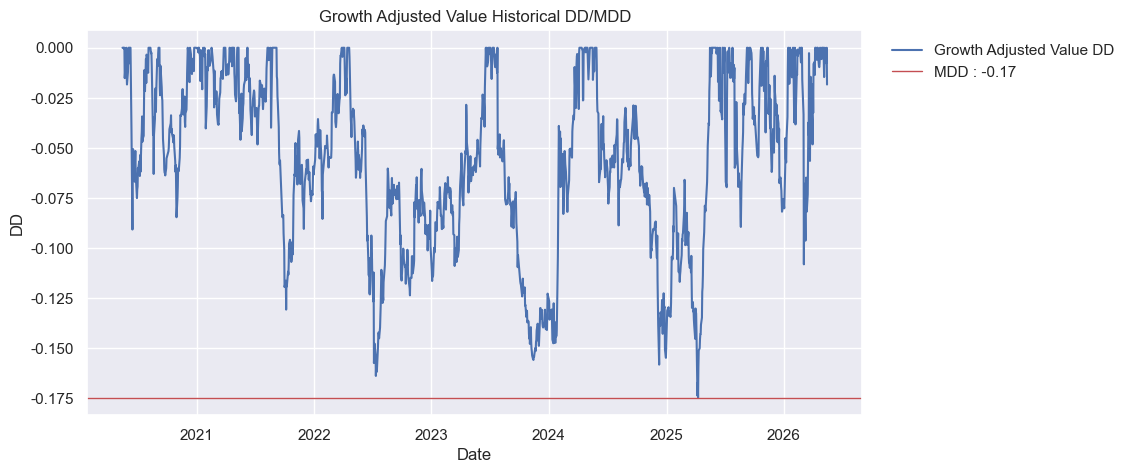

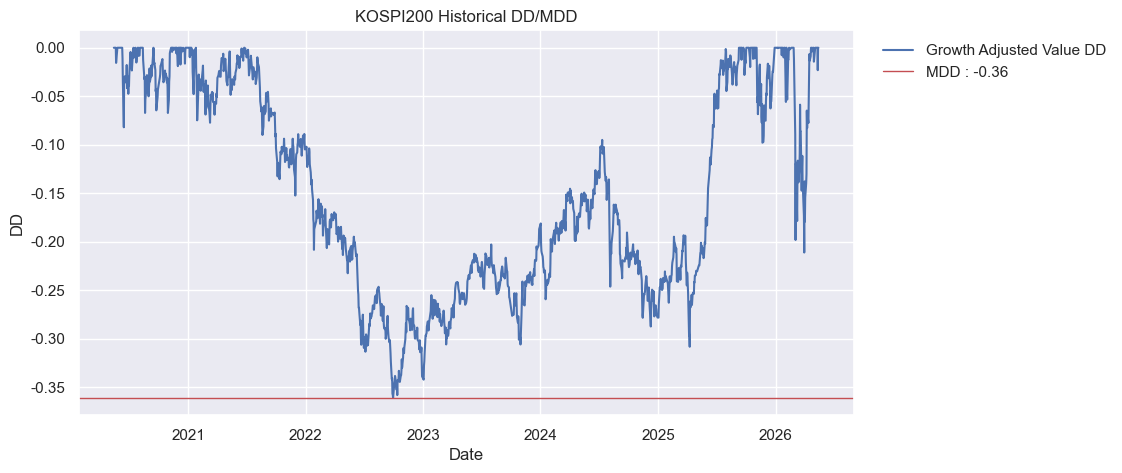

In [30]:
show_mdd(pnl_series.pct_change(), 'Growth Adjusted Value')
show_mdd(kospi_pnl.pct_change()['^KS200'], 'KOSPI200')